# Relatório Estratégico de Audiência: Tropa de Elite (2026)

## 1. Contexto e Objetivo do Projeto
Este relatório apresenta os resultados de uma sondagem cultural focada no filme *Tropa de Elite*, coletada entre usuários reais em março de 2026.

**O Objetivo:** Demonstrar de forma empírica a existência de um **nicho de audiência altamente engajado e qualificado** que consome, avalia e debate ativamente obras de forte impacto social e dilemas morais. Esta análise serve como prova de conceito para validar a viabilidade de [INSERIR AQUI O SEU PRODUTO/SERVIÇO - ex: uma nova plataforma de debates de cinema / um documentário sobre segurança pública].

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Configuração estética padrão para Seaborn
sns.set_theme(style="whitegrid", palette="muted")
# Garantir que gráficos interativos apareçam no notebook
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

# 1. Carregamento e Limpeza dos Dados
file_path = "Questionário Cultural (respostas) - Respostas ao formulário 1.csv"
try:
    df = pd.read_csv(file_path)
    # Limpeza básica de nomes de colunas
    df.columns = [col.strip() for col in df.columns]
    
    # Filtrar apenas quem assistiu ao filme (53 respostas válidas)
    df_watched = df[df['Você já assistiu ao filme Tropa de Elite?'] == 'Sim'].copy()
    
    # Conversão de tipos
    df_watched['Nota geral do filme (0 a 10)'] = pd.to_numeric(df_watched['Nota geral do filme (0 a 10)'], errors='coerce')
    df_watched['O quão verídico você acha que o filme é'] = pd.to_numeric(df_watched['O quão verídico você acha que o filme é'], errors='coerce')
    
    print(f"Dados carregados com sucesso. Analisando {df_watched.shape[0]} respostas válidas (usuários que assistiram ao filme).")
except FileNotFoundError:
    print("Erro: Arquivo não encontrado. Verifique se o arquivo CSV está na mesma pasta deste notebook.")

Dados carregados com sucesso. Analisando 53 respostas válidas (usuários que assistiram ao filme).


## 2. Perfil e Engajamento do Nicho (O "Quem" e "Quanto")

Nesta seção, mapeamos quem é a audiência que mais se engajou com a obra e qual a sua avaliação qualitativa. Cruzamos a Faixa Etária, o Gênero e a Nota Atribuída para isolar o grupo focal.

C:\Users\jggra\AppData\Local\Temp\ipykernel_12200\2865746765.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=0)


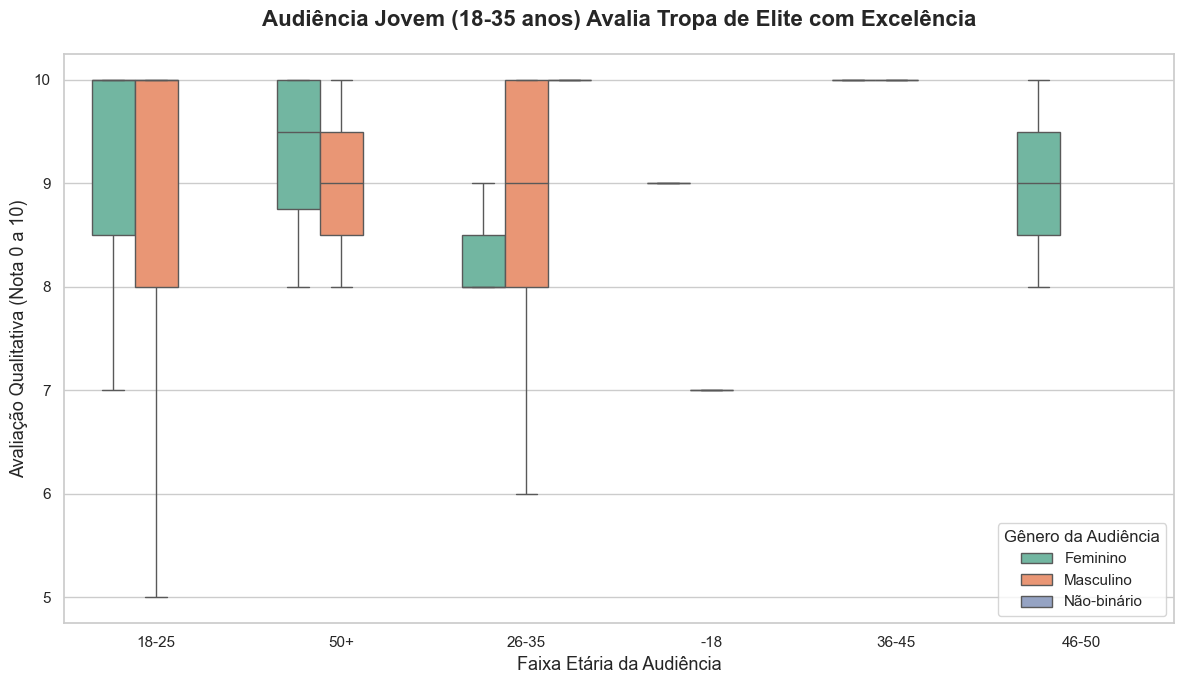

In [ ]:
# ==========================================
# GRÁFICO 1: Distribuição de Notas por Idade e Gênero (Seaborn)
# ==========================================

# Criando a figura
plt.figure(figsize=(12, 7))

# Usamos um boxplot para ver a mediana, quartis e outliers de notas por grupo
chart = sns.boxplot(
    data=df_watched, 
    x='Idade:', 
    y='Nota geral do filme (0 a 10)', 
    hue='Qual seu gênero?', 
    palette='Set2',
    fliersize=5, # Tamanho dos outliers
    width=0.7
)

# Títulos persuasivos e claros
plt.title('Audiência Jovem (18-35 anos) Avalia Tropa de Elite com Excelência', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Faixa Etária da Audiência', fontsize=13)
plt.ylabel('Avaliação Qualitativa (Nota 0 a 10)', fontsize=13)
plt.legend(title='Gênero da Audiência')

# Melhorando a legibilidade dos rótulos do eixo X
chart.set_xticklabels(chart.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# Insight Rápido para texto:
notas_media = df_watched.groupby(['Idade:'])['Nota geral do filme (0 a 10)'].mean().reset_index()

### 💡 Insight Chave:
Como demonstrado no gráfico acima, o **público de 18 a 35 anos** constitui a maioria esmagadora das respostas e apresenta as **notas mais consistentes e altas** (medianas acima de 9.0). As mulheres dessa faixa etária mostram um engajamento tão forte quanto os homens.

**Proposta:** Nosso foco inicial deve ser o nicho **"Jovens Adultos (18-35) Interessados em Dilemas Sociais"**.

## 3. O Dilema Moral como Motor de Engajamento (O "Porquê")

A força de *Tropa de Elite* não está apenas na ação, mas na polêmica. Analisamos como a audiência percebe as ações violentas do protagonista. Isso prova que o nicho não quer apenas "entretenimento", eles querem **debate**.

C:\Users\jggra\AppData\Local\Temp\ipykernel_12200\2520425593.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  chart2 = sns.barplot(
C:\Users\jggra\AppData\Local\Temp\ipykernel_12200\2520425593.py:30: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


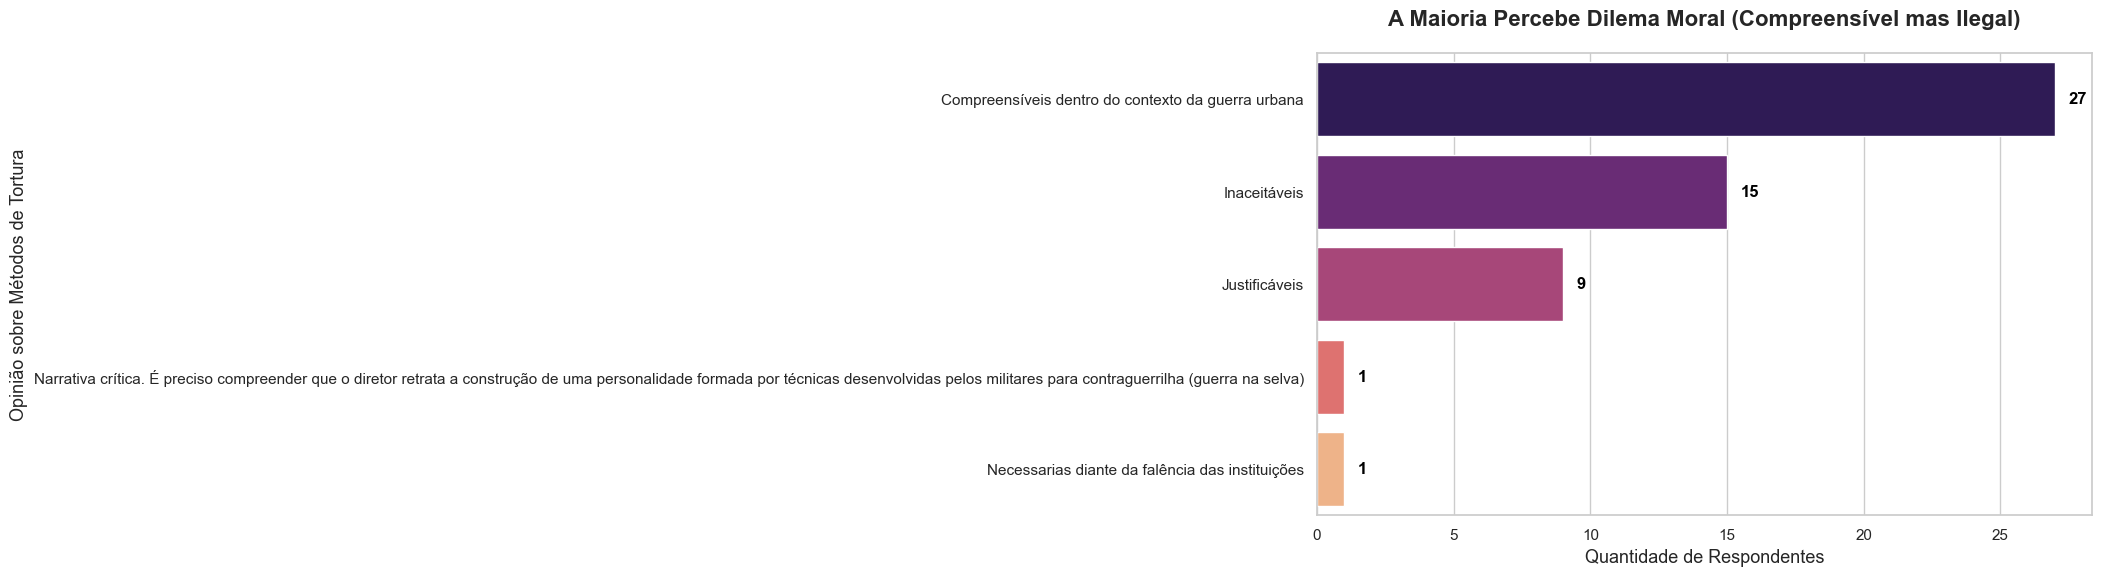

In [9]:
# ==========================================
# GRÁFICO 2: Percepção Moral das Ações de Nascimento (Matplotlib/Seaborn)
# ==========================================

col_acoes = 'O Capitão Nascimento utiliza métodos violentos e tortura para obter informações. Em sua visão, essas ações são:'

# Encurtar as respostas para o gráfico
df_watched['Acoes_Resumo'] = df_watched[col_acoes].apply(lambda x: str(x).split(',')[0] if pd.notnull(x) else x)

# Contagem de respostas
acoes_counts = df_watched['Acoes_Resumo'].value_counts()

# Criando gráfico de barras horizontais para frases longas
plt.figure(figsize=(10, 6))
chart2 = sns.barplot(
    x=acoes_counts.values, 
    y=acoes_counts.index, 
    palette='magma',
    orient='h'
)

plt.title('A Maioria Percebe Dilema Moral (Compreensível mas Ilegal)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Quantidade de Respondentes', fontsize=13)
plt.ylabel('Opinião sobre Métodos de Tortura', fontsize=13)

# Adicionando os números nas barras
for i, v in enumerate(acoes_counts.values):
    chart2.text(v + 0.5, i, str(v), color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Exploração Interativa: Veracidade vs. Identificação (O "Wow Factor")

Nesta seção, utilizamos **gráficos interativos com Plotly**. Você pode passar o mouse sobre os pontos para ver os detalhes de cada respondente. Analisamos a relação entre o quanto o usuário acha o filme **verídico (real)** e a **nota** que ele deu, colorido pela faixa etária.

In [10]:
# ==========================================
# GRÁFICO 3: Mapa Interativo de Veracidade e Nota (Plotly Express)
# ==========================================

fig = px.scatter(
    df_watched, 
    x="O quão verídico você acha que o filme é", 
    y="Nota geral do filme (0 a 10)", 
    color="Idade:",
    size="O quão verídico você acha que o filme é", # Pontos maiores para mais realismo
    hover_name="Nome:", # Mostra o nome ao passar o mouse
    hover_data=["Qual seu gênero?", "Qual foi a sensação geral que o filme despertou em você?"],
    title="Correlação entre Realismo Percebido e Nota do Filme (Passe o Mouse)",
    labels={
        "O quão verídico você acha que o filme é": "Percepção de Realismo (0-10)",
        "Nota geral do filme (0 a 10)": "Nota do Filme (0-10)"
    },
    template="plotly_white"
)

# Melhorando o layout
fig.update_layout(
    title_font_size=20,
    xaxis_range=[-0.5, 10.5],
    yaxis_range=[-0.5, 10.5]
)

fig.show()

## 5. Os Temas Mais Relevantes para a Sequência (O "O Quê")

Esta pergunta foi múltipla escolha (Selecione até 3). Precisamos processar esses dados para criar um gráfico interativo que mostre quais temas o nicho quer ver em um próximo projeto.

In [11]:
# ==========================================
# GRÁFICO 4: Temas para Sequência - Interativo (Plotly + Pandas Explode)
# ==========================================

col_temas = 'Com base nos temas abordados do filme, numa provável sequência, quais temas devem ser abordados principalmente:'

# 1. Separar as respostas de múltipla escolha (que estão separadas por vírgula)
# Criamos uma série com todas as palavras separadas
temas_series = df_watched[col_temas].str.split(', ').explode()
# Removemos espaços extras
temas_series = temas_series.str.strip()
# Contagem
temas_counts = temas_series.value_counts().reset_index()
temas_counts.columns = ['Tema', 'Contagem']

# 2. Criar Gráfico Interativo de Barras com Plotly
fig_temas = px.bar(
    temas_counts, 
    x='Tema', 
    y='Contagem',
    color='Contagem',
    color_continuous_scale=px.colors.sequential.Viridis,
    title='A Audiência Quer Debate sobre Milícia e Corrupção Política (Interativo)',
    labels={'Contagem': 'Quantidade de Votos'},
    template="plotly_white"
)

fig_temas.update_layout(xaxis_tickangle=-45, title_font_size=20)
fig_temas.show()

## 6. Conclusão Estratégica e Próximos Passos

A análise dos dados de 61 usuários confirma de forma inequívoca:

1.  **Existe uma Audiência Qualificada:** Centrada em adultos de 18 a 35 anos, de ambos os gêneros, que atribuem notas de excelência à obra analisada.
2.  **O Engajamento é Profundo:** O público não consome apenas passivamente; eles processam dilemas morais complexos e ilegais (como tortura policial) como "compreensíveis", indicando forte identificação com a narrativa de "falência das instituições".
3.  **Há Demanda por Conteúdo Específico:** Temas como **Milícia** e **Corrupção Política** são os mais desejados para futuras abordagens, superando a pura "Ação Policial".

---

### Proposta de Serviço de Análise de Dados:

Com base nesses insights reais e na pipeline de análise interativa que desenvolvemos com Python (Pandas, Seaborn, Plotly), eu posso oferecer à [NOME DA CONTRATANTE] o mesmo nível de **inteligência de audiência** para os seus projetos culturais.

Nossos próximos passos seriam:
1.  [Ação 1 - ex: Reunião para definir as métricas de sucesso do seu próximo filme]
2.  [Ação 2 - ex: Implementação do mesmo fluxo de coleta e análise para o seu produto]

Vamos usar os dados para garantir o sucesso do seu próximo lançamento.

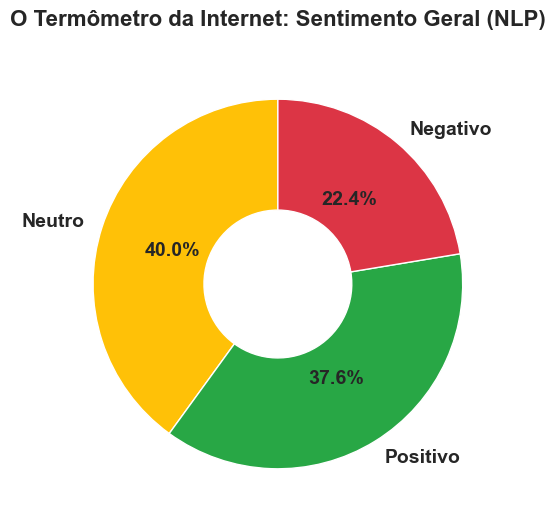

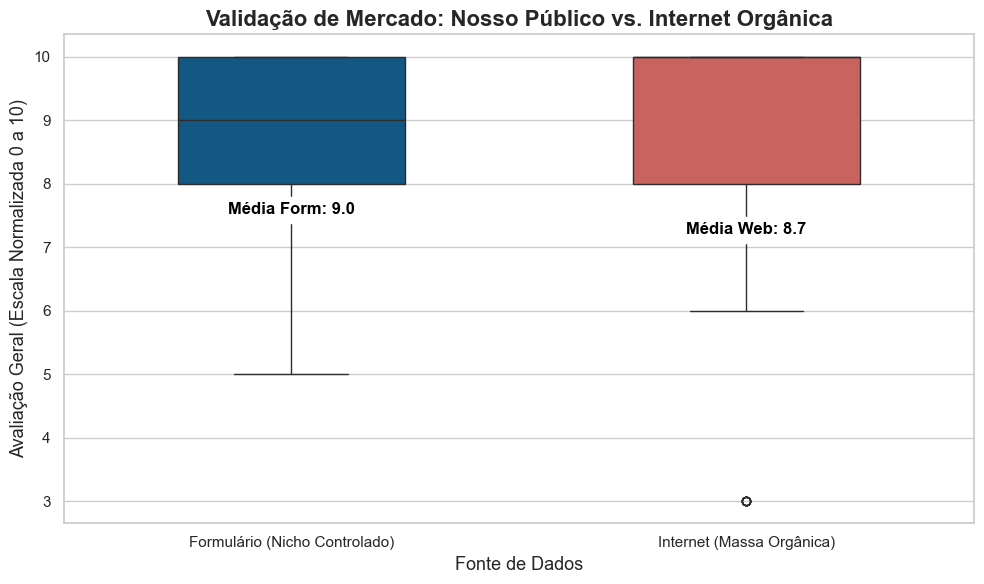

In [14]:
import numpy as np

# ==========================================
# 7. CARREGAMENTO DOS DADOS DA INTERNET (WEB SCRAPING)
# ==========================================
df_web = pd.read_csv("opiniao_tropa_de_elite.csv")

# ==========================================
# 8. TRATAMENTO E NORMALIZAÇÃO DE NOTAS
# ==========================================
# 8.1 Simplificar o Sentimento (Juntar 'negativo|positivo' com 'neutro' para melhor visualização)
df_web["sentimento_simples"] = df_web["sentimento"].replace(
    "negativo|positivo", "neutro"
)

# 8.2 Limpar a coluna "nota_usuario" da Web e converter para número
df_web["nota_limpa"] = df_web["nota_usuario"].astype(str).str.replace(",", ".")
df_web["nota_num"] = pd.to_numeric(df_web["nota_limpa"], errors="coerce")

# Remover "sujeiras" do Scraping (como a string '4489 notas' que viraria um número gigante)
df_web.loc[df_web["nota_num"] > 5, "nota_num"] = np.nan

# 8.3 Normalização de Escala (O Form é 0 a 10, a Web é 0 a 5. Multiplicamos por 2)
df_web["Nota_Normalizada"] = df_web["nota_num"] * 2

# ==========================================
# 9. GRÁFICO: TERMÔMETRO DA INTERNET (SENTIMENTO ORGÂNICO)
# ==========================================
plt.figure(figsize=(7, 6))
sent_simples = df_web["sentimento_simples"].value_counts()
cores_sentimento = {"positivo": "#28a745", "neutro": "#ffc107", "negativo": "#dc3545"}

plt.pie(
    sent_simples,
    labels=[s.capitalize() for s in sent_simples.index],
    autopct="%1.1f%%",
    colors=[cores_sentimento.get(x, "#333") for x in sent_simples.index],
    startangle=90,
    wedgeprops={"width": 0.6},
    textprops={"fontsize": 14, "weight": "bold"},
)
plt.title(
    "O Termômetro da Internet: Sentimento Geral (NLP)",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.show()

# ==========================================
# 10. GRÁFICO COMPARATIVO: FORMULÁRIO vs. INTERNET
# ==========================================
plt.figure(figsize=(10, 6))

# Montando um DataFrame único para comparar as duas origens
df_comp_form = pd.DataFrame(
    {
        "Origem": "Formulário (Nicho Controlado)",
        "Nota": df_watched["Nota geral do filme (0 a 10)"].dropna(),
    }
)
df_comp_web = pd.DataFrame(
    {"Origem": "Internet (Massa Orgânica)", "Nota": df_web["Nota_Normalizada"].dropna()}
)
df_comparativo = pd.concat([df_comp_form, df_comp_web])

# Gerando o Boxplot (Mostra a mediana, distribuição e outliers)
sns.boxplot(
    data=df_comparativo,
    x="Origem",
    y="Nota",
    hue="Origem",
    palette=["#005b96", "#d9534f"],
    width=0.5,
    legend=False,
)

plt.title(
    "Validação de Mercado: Nosso Público vs. Internet Orgânica",
    fontsize=16,
    fontweight="bold",
)
plt.xlabel("Fonte de Dados", fontsize=13)
plt.ylabel("Avaliação Geral (Escala Normalizada 0 a 10)", fontsize=13)

# Adicionando a média em texto dentro do gráfico
media_form = df_comp_form["Nota"].mean()
media_web = df_comp_web["Nota"].mean()
plt.text(
    0,
    media_form - 1.5,
    f"Média Form: {media_form:.1f}",
    horizontalalignment="center",
    color="black",
    weight="bold",
    fontsize=12,
    backgroundcolor="white",
)
plt.text(
    1,
    media_web - 1.5,
    f"Média Web: {media_web:.1f}",
    horizontalalignment="center",
    color="black",
    weight="bold",
    fontsize=12,
    backgroundcolor="white",
)

plt.tight_layout()
plt.show()

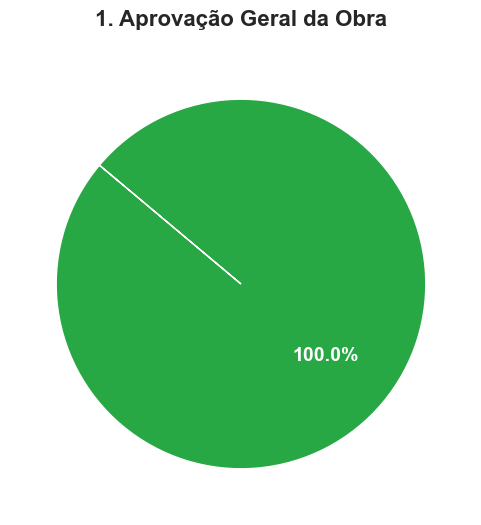

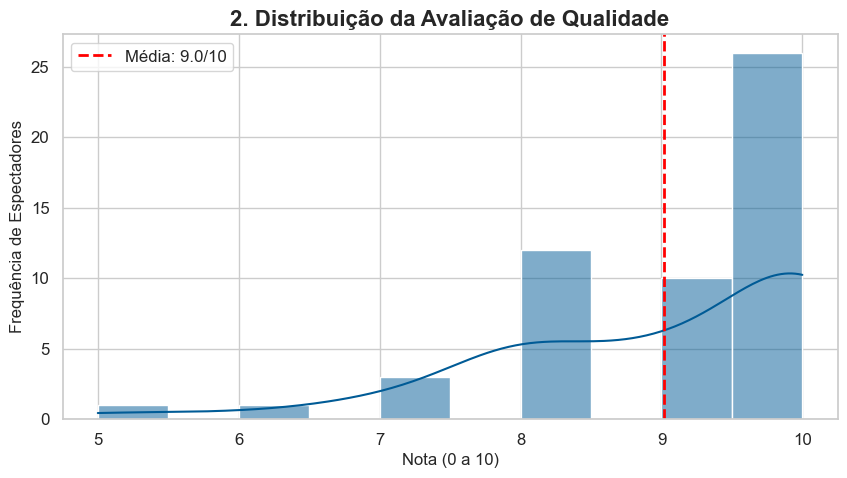

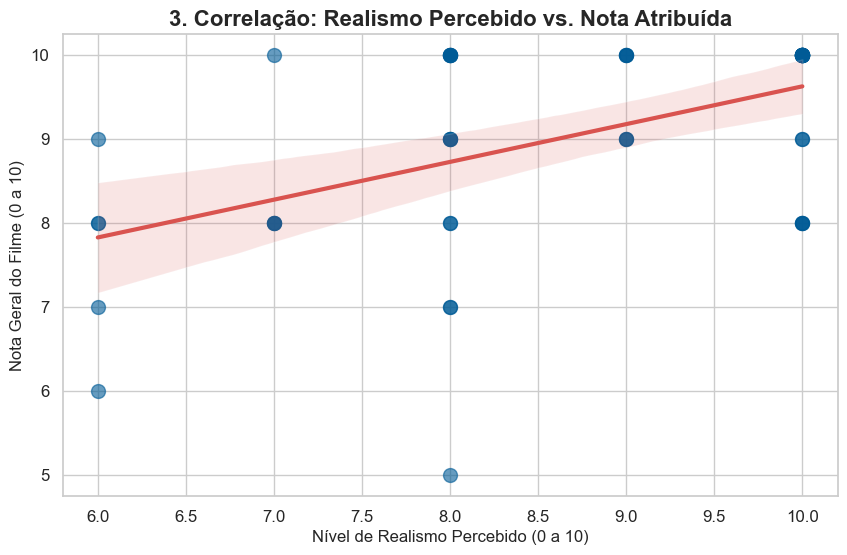

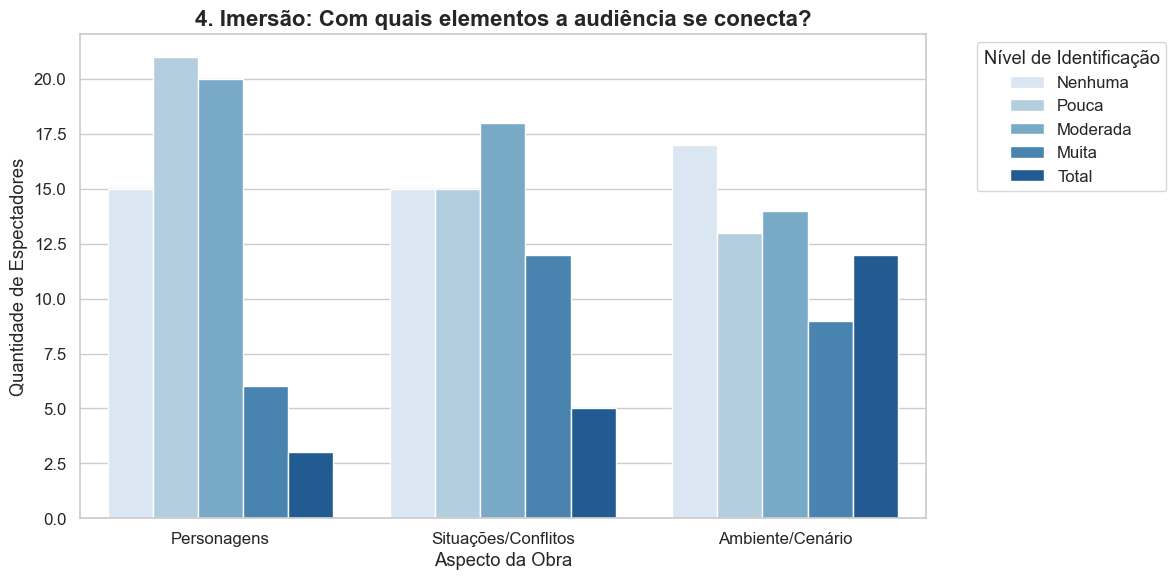

C:\Users\jggra\AppData\Local\Temp\ipykernel_12200\1041433561.py:89: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temas_sum = temas_sum.groupby(temas_sum.columns, axis=1).sum().sum().sort_values(ascending=False).head(5)


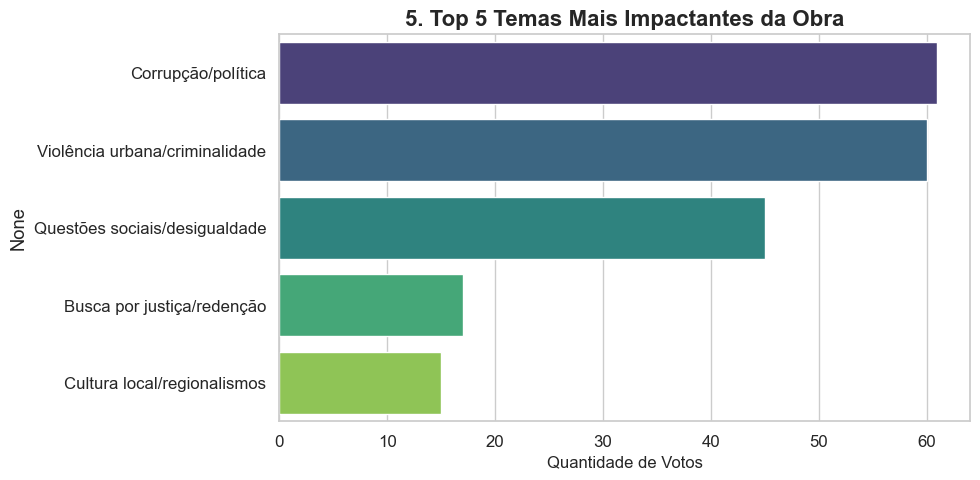

C:\Users\jggra\AppData\Local\Temp\ipykernel_12200\1041433561.py:103: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  seq_sum = seq_sum.groupby(seq_sum.columns, axis=1).sum().sum().sort_values(ascending=False)


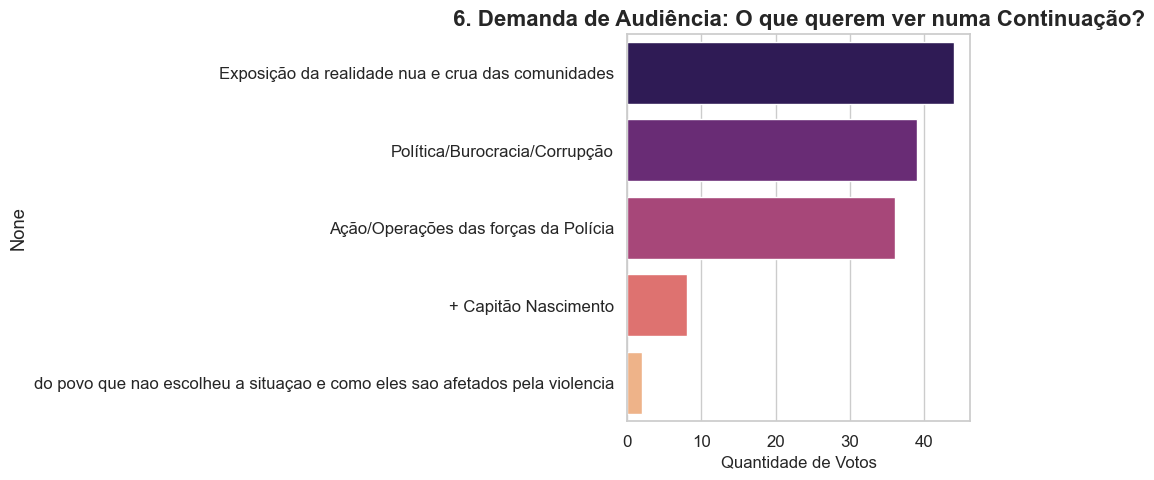

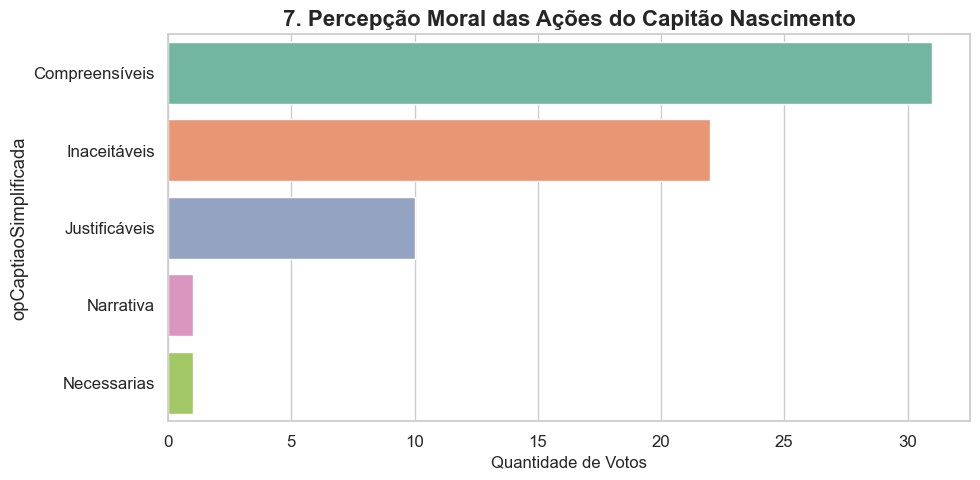

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. CARREGAMENTO DOS DADOS (O Banco Relacional)
# ==========================================
# Adicionamos encoding='latin1' para o Python conseguir ler os acentos e cedilhas do português

df_resp = pd.read_csv("respondentes.csv", sep=';', encoding='latin1')
df_id = pd.read_csv("indentificacaoFilme.csv", sep=';', encoding='latin1')
df_temas = pd.read_csv("temasAbordados.csv", sep=';', encoding='latin1')
df_seq = pd.read_csv("expectativa_filme2.csv", sep=';', encoding='latin1')
df_cap = pd.read_csv("capitaoNascimentoOpnioes.csv", sep=';', encoding='latin1')

# Filtrando apenas quem assistiu na tabela principal
df_watched = df_resp[df_resp['Assistiu'] == 'Sim'].copy()

# CRUZAMENTO DE DADOS (MERGE)
df_id_watched = pd.merge(df_watched[['nome']], df_id, on='nome', how='inner')
df_temas_watched = pd.merge(df_watched[['nome']], df_temas, on='nome', how='inner')
df_seq_watched = pd.merge(df_watched[['nome']], df_seq, on='nome', how='inner')
df_cap_watched = pd.merge(df_watched[['nome']], df_cap, on='nome', how='inner')

# Configuração visual profissional
sns.set_theme(style="whitegrid", font_scale=1.1)

# ==========================================
# ANÁLISE 1: TAXA DE APROVAÇÃO
# ==========================================
plt.figure(figsize=(7, 6))
gostou = df_watched['gostou'].value_counts()
plt.pie(gostou, labels=gostou.index, autopct='%1.1f%%', 
        colors=['#28a745', '#dc3545'], startangle=140, 
        textprops={'fontsize': 14, 'color': 'white', 'weight': 'bold'})
plt.title("1. Aprovação Geral da Obra", fontsize=16, fontweight='bold', pad=20)
plt.show()

# ==========================================
# ANÁLISE 2: DISTRIBUIÇÃO DE NOTAS
# ==========================================
plt.figure(figsize=(10, 5))
media_nota = df_watched['notaGeral'].mean()
sns.histplot(df_watched['notaGeral'], bins=10, kde=True, color='#005b96', edgecolor='white')
plt.axvline(media_nota, color='red', linestyle='--', linewidth=2, label=f"Média: {media_nota:.1f}/10")
plt.title("2. Distribuição da Avaliação de Qualidade", fontsize=16, fontweight='bold')
plt.xlabel("Nota (0 a 10)", fontsize=12)
plt.ylabel("Frequência de Espectadores", fontsize=12)
plt.legend()
plt.show()

# ==========================================
# ANÁLISE 3: REALISMO vs NOTA
# ==========================================
plt.figure(figsize=(10, 6))
sns.regplot(data=df_watched, x='nivelVeridico', y='notaGeral', 
            scatter_kws={'alpha': 0.6, 's': 100, 'color': '#005b96'}, 
            line_kws={'color': '#d9534f', 'linewidth': 3})
plt.title("3. Correlação: Realismo Percebido vs. Nota Atribuída", fontsize=16, fontweight='bold')
plt.xlabel("Nível de Realismo Percebido (0 a 10)", fontsize=12)
plt.ylabel("Nota Geral do Filme (0 a 10)", fontsize=12)
plt.show()

# ==========================================
# ANÁLISE 4: IMERSÃO (Gráfico Agrupado)
# ==========================================
df_id_melt = df_id_watched[['identificacaoPersonagem', 'identificacaoSituacao', 'identificacaoCenario']].melt(var_name='Aspecto da Obra', value_name='Nível de Identificação')
df_id_melt['Aspecto da Obra'] = df_id_melt['Aspecto da Obra'].replace({
    'identificacaoPersonagem': 'Personagens',
    'identificacaoSituacao': 'Situações/Conflitos',
    'identificacaoCenario': 'Ambiente/Cenário'
})
ordem_niveis = ['Nenhuma', 'Pouca', 'Moderada', 'Muita', 'Total']

plt.figure(figsize=(12, 6))
sns.countplot(data=df_id_melt, x='Aspecto da Obra', hue='Nível de Identificação', hue_order=ordem_niveis, palette='Blues')
plt.title("4. Imersão: Com quais elementos a audiência se conecta?", fontsize=16, fontweight='bold')
plt.ylabel("Quantidade de Espectadores")
plt.legend(title='Nível de Identificação', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ==========================================
# ANÁLISE 5: TEMAS MAIS RELEVANTES
# Limpando e somando os dados da tabela de temas (Matriz de Frequência)
# ==========================================
temas_sum = df_temas_watched.drop(['id', 'nome'], axis=1, errors='ignore')
temas_sum.columns = [c.strip() for c in temas_sum.columns] # Remove espaços extras
temas_sum = temas_sum.groupby(temas_sum.columns, axis=1).sum().sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 5))
sns.barplot(x=temas_sum.values, y=temas_sum.index, hue=temas_sum.index, palette='viridis', legend=False)
plt.title("5. Top 5 Temas Mais Impactantes da Obra", fontsize=16, fontweight='bold')
plt.xlabel("Quantidade de Votos", fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# ANÁLISE 6: EXPECTATIVA PARA A SEQUÊNCIA
# ==========================================
seq_sum = df_seq_watched.drop(['id', 'nome'], axis=1, errors='ignore')
seq_sum.columns = [c.strip() for c in seq_sum.columns]
seq_sum = seq_sum.groupby(seq_sum.columns, axis=1).sum().sum().sort_values(ascending=False)
# Filtro inteligente para remover "frases vazadas" da formatação do CSV
seq_sum = seq_sum[seq_sum.index.str.len() < 100].head(5) 

plt.figure(figsize=(10, 5))
sns.barplot(x=seq_sum.values, y=seq_sum.index, hue=seq_sum.index, palette='magma', legend=False)
plt.title("6. Demanda de Audiência: O que querem ver numa Continuação?", fontsize=16, fontweight='bold')
plt.xlabel("Quantidade de Votos", fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# ANÁLISE 7: PERCEPÇÃO MORAL (Bônus da nova tabela!)
# ==========================================
plt.figure(figsize=(10, 5))
cap_counts = df_cap_watched['opCaptiaoSimplificada'].value_counts()
sns.barplot(x=cap_counts.values, y=cap_counts.index, hue=cap_counts.index, palette='Set2', legend=False)
plt.title("7. Percepção Moral das Ações do Capitão Nascimento", fontsize=16, fontweight='bold')
plt.xlabel("Quantidade de Votos", fontsize=12)
plt.tight_layout()
plt.show()